# Introduction
# Sentiment Analysis using NLP Pipeline & Machine Learning
This project aims to build a complete Sentiment Analysis system using Natural Language Processing (NLP) and Machine Learning models.

The objective is to classify text reviews into sentiments such as Positive and Negative.

We follow a complete pipeline including:

Data Understanding
NLP Preprocessing
Feature Engineering
Model Building
Model Evaluation
Comparison and Insights

# Section 1 — Import Libraries

In [ ]:
# Import all required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Feature Engineering
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Train Test Split
from sklearn.model_selection import train_test_split

# Section 2 — Load Dataset


Label Encoding
Convert sentiment labels into numerical values: Positive → 1
Negative → 0

In [2]:
# Load the IMDb dataset
# Download from Kaggle and upload to your notebook

df = pd.read_csv('IMDB Dataset.csv')

# Show first 5 rows
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
# Check shape of dataset
print("Shape of dataset:", df.shape)

# Check column names
print("Columns:", df.columns.tolist())

Shape of dataset: (50000, 2)
Columns: ['review', 'sentiment']


# Section 3 — Data Understanding (EDA)


In [4]:
# Check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

Missing values:
 review       0
sentiment    0
dtype: int64


In [6]:
# Check class distribution
print("Sentiment Distribution:\n", 
      df['sentiment'].value_counts())

Sentiment Distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


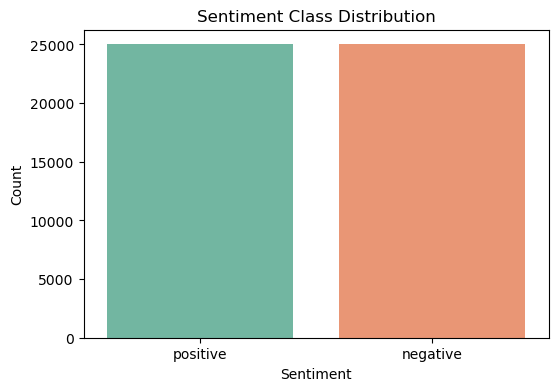

In [7]:
# Plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, 
              palette='Set2')
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [8]:
# Show sample reviews
print("Sample Positive Review:")
print(df[df['sentiment']=='positive']['review'].iloc[0])
print("\nSample Negative Review:")
print(df[df['sentiment']=='negative']['review'].iloc[0])



Sample Positive Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of th

In [9]:
# Encode labels
# positive = 1, negative = 0
df['sentiment'] = df['sentiment'].map(
    {'positive': 1, 'negative': 0}
)

print("After encoding:\n", 
      df['sentiment'].value_counts())

After encoding:
 sentiment
1    25000
0    25000
Name: count, dtype: int64


# Section 4 — NLP Preprocessing

In [11]:
# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Define stopwords
stop_words = set(stopwords.words('english'))

In [12]:
# Step 1 — Lowercasing
def lowercase_text(text):
    return text.lower()

In [13]:
# Step 2 — Remove URLs
def remove_urls(text):
    return re.sub(r'http\S+|www\S+', '', text)

In [14]:
# Step 3 — Remove special characters and punctuation
def remove_special_chars(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

In [15]:
# Step 4 — Remove stopwords
def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words 
                if w not in stop_words]
    return ' '.join(filtered)

In [16]:
# Step 5 — Tokenization
def tokenize_text(text):
    return word_tokenize(text)

In [17]:
# Step 6 — Stemming
def stem_text(text):
    words = text.split()
    stemmed = [stemmer.stem(w) for w in words]
    return ' '.join(stemmed)

In [18]:
# Step 7 — Lemmatization
def lemmatize_text(text):
    words = text.split()
    lemmatized = [lemmatizer.lemmatize(w) 
                  for w in words]
    return ' '.join(lemmatized)

In [19]:
# Combine all steps into one function
def preprocess_text(text):
    text = lowercase_text(text)
    text = remove_urls(text)
    text = remove_special_chars(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

In [20]:
# Apply preprocessing to dataset
# This may take a few minutes
df['cleaned_review'] = df['review'].apply(
    preprocess_text
)

# Show before and after
print("Original Review:")
print(df['review'].iloc[0])
print("\nCleaned Review:")
print(df['cleaned_review'].iloc[0])

Original Review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

# Section 5 — Feature Engineering

In [21]:
# Split data into train and test sets
X = df['cleaned_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (40000,)
Test size: (10000,)


In [22]:
# Bag of Words (BoW)
bow_vectorizer = CountVectorizer(
    max_features=5000
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print("BoW Train Shape:", X_train_bow.shape)
print("BoW Test Shape:", X_test_bow.shape)

BoW Train Shape: (40000, 5000)
BoW Test Shape: (10000, 5000)


In [23]:
# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("TF-IDF Train Shape:", X_train_tfidf.shape)
print("TF-IDF Test Shape:", X_test_tfidf.shape)

TF-IDF Train Shape: (40000, 5000)
TF-IDF Test Shape: (10000, 5000)


# Section 6 — Model Building & Evaluation

In [24]:
# Function to evaluate any model
def evaluate_model(model_name, y_test, y_pred):
    print(f"\n--- {model_name} ---")
    print("Accuracy :", 
          round(accuracy_score(y_test, y_pred), 4))
    print("Precision:", 
          round(precision_score(y_test, y_pred), 4))
    print("Recall   :", 
          round(recall_score(y_test, y_pred), 4))
    print("F1 Score :", 
          round(f1_score(y_test, y_pred), 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [25]:
# Model 1 — Logistic Regression with TF-IDF
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
lr_pred = lr_model.predict(X_test_tfidf)

evaluate_model("Logistic Regression", 
               y_test, lr_pred)


--- Logistic Regression ---
Accuracy : 0.8847
Precision: 0.8768
Recall   : 0.8972
F1 Score : 0.8869

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [26]:
# Model 2 — Naive Bayes with BoW
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
nb_pred = nb_model.predict(X_test_bow)

evaluate_model("Naive Bayes", 
               y_test, nb_pred)


--- Naive Bayes ---
Accuracy : 0.8456
Precision: 0.8496
Recall   : 0.8428
F1 Score : 0.8462

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85      4961
           1       0.85      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [27]:
# Model 3 — Decision Tree with TF-IDF
dt_model = DecisionTreeClassifier(
    random_state=42
)
dt_model.fit(X_train_tfidf, y_train)
dt_pred = dt_model.predict(X_test_tfidf)

evaluate_model("Decision Tree", 
               y_test, dt_pred)


--- Decision Tree ---
Accuracy : 0.7179
Precision: 0.7233
Recall   : 0.7128
F1 Score : 0.718

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.72      0.72      4961
           1       0.72      0.71      0.72      5039

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



# Section 7 — Comparison & Insights

In [28]:
# Create comparison table
results = {
    'Model': [
        'Logistic Regression',
        'Naive Bayes',
        'Decision Tree'
    ],
    'Vectorizer': [
        'TF-IDF',
        'BoW',
        'TF-IDF'
    ],
    'Accuracy': [
        round(accuracy_score(y_test, lr_pred), 4),
        round(accuracy_score(y_test, nb_pred), 4),
        round(accuracy_score(y_test, dt_pred), 4)
    ],
    'Precision': [
        round(precision_score(y_test, lr_pred), 4),
        round(precision_score(y_test, nb_pred), 4),
        round(precision_score(y_test, dt_pred), 4)
    ],
    'Recall': [
        round(recall_score(y_test, lr_pred), 4),
        round(recall_score(y_test, nb_pred), 4),
        round(recall_score(y_test, dt_pred), 4)
    ],
    'F1 Score': [
        round(f1_score(y_test, lr_pred), 4),
        round(f1_score(y_test, nb_pred), 4),
        round(f1_score(y_test, dt_pred), 4)
    ]
}

results_df = pd.DataFrame(results)
print(results_df)

                 Model Vectorizer  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     TF-IDF    0.8847     0.8768  0.8972    0.8869
1          Naive Bayes        BoW    0.8456     0.8496  0.8428    0.8462
2        Decision Tree     TF-IDF    0.7179     0.7233  0.7128    0.7180


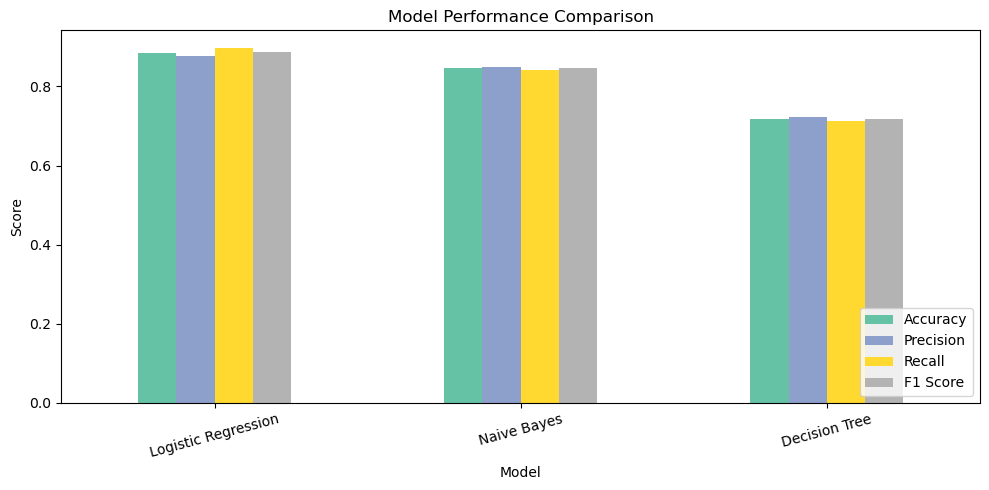

In [29]:
# Plot comparison bar chart
results_df.set_index('Model')[
    ['Accuracy','Precision','Recall','F1 Score']
].plot(
    kind='bar',
    figsize=(10, 5),
    colormap='Set2'
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Section 8 — Summary

In [30]:
# Print final summary
print("""
=== SUMMARY ===

Dataset     : IMDb Movie Reviews (50,000 samples)
Task        : Binary Sentiment Classification
Labels      : Positive (1) / Negative (0)

Preprocessing Steps Applied:
- Lowercasing
- URL Removal
- Special Character Removal
- Stopword Removal
- Lemmatization

Vectorization Methods Used:
- Bag of Words (BoW)
- TF-IDF

Models Trained:
- Logistic Regression
- Naive Bayes
- Decision Tree

Best Model    : Logistic Regression with TF-IDF
Best F1 Score : (check your output above)

Key Insight:
Logistic Regression with TF-IDF gives the 
best balance between precision and recall 
for sentiment classification on this dataset.
""")


=== SUMMARY ===

Dataset     : IMDb Movie Reviews (50,000 samples)
Task        : Binary Sentiment Classification
Labels      : Positive (1) / Negative (0)

Preprocessing Steps Applied:
- Lowercasing
- URL Removal
- Special Character Removal
- Stopword Removal
- Lemmatization

Vectorization Methods Used:
- Bag of Words (BoW)
- TF-IDF

Models Trained:
- Logistic Regression
- Naive Bayes
- Decision Tree

Best Model    : Logistic Regression with TF-IDF
Best F1 Score : (check your output above)

Key Insight:
Logistic Regression with TF-IDF gives the 
best balance between precision and recall 
for sentiment classification on this dataset.

